In [1]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer# converting text
from sklearn.linear_model import LogisticRegression 

In [3]:
df = pd.read_csv("spam.csv")

# Prevent train/test leakage from repeated messages
df = df.drop_duplicates(subset=["Message"]).reset_index(drop=True)

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print(df.dtypes)

Category    object
Message     object
dtype: object


In [4]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [5]:
df['label']=df['Category'].map({'ham':0,'spam':1})

In [10]:
X = df["Message"].astype(str)  # input data model will learn from
y = df["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Stronger text features for phishing/spam-like content
# - word n-grams capture phrases like "verify account"
# - char n-grams capture obfuscation like "ver1fy" / spaced words / weird punctuation
from sklearn.pipeline import FeatureUnion

vectorizer = FeatureUnion(
    [
        (
            "word_tfidf",
            TfidfVectorizer(
                analyzer="word",
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                strip_accents="unicode",
            ),
        ),
        (
            "char_tfidf",
            TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(3, 5),
                min_df=2,
                sublinear_tf=True,
            ),
        ),
    ]
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear")
model.fit(X_train_vec, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, solver='liblinear')

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    classification_report,
)

# Probabilities (needed for PR-AUC and later threshold tuning)
y_proba = model.predict_proba(X_test_vec)[:, 1]

# Default threshold (you'll tune later)
threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("PR-AUC (Average Precision):", average_precision_score(y_test, y_proba))

print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=["ham", "spam"]))

Accuracy: 0.9786821705426356
Precision: 0.9344262295081968
Recall: 0.890625
F1: 0.912
PR-AUC (Average Precision): 0.9668876165824669

Classification report:
               precision    recall  f1-score   support

         ham       0.98      0.99      0.99       904
        spam       0.93      0.89      0.91       128

    accuracy                           0.98      1032
   macro avg       0.96      0.94      0.95      1032
weighted avg       0.98      0.98      0.98      1032



In [16]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Threshold sweep to choose a security-friendly operating point
thresholds = np.linspace(0.1, 0.9, 17)  # 0.10, 0.15, ..., 0.90
print("thr\tprec\trecall\tf1")

best_for_recall = None
for thr in thresholds:
    y_thr = (y_proba >= thr).astype(int)
    prec = precision_score(y_test, y_thr)
    rec = recall_score(y_test, y_thr)
    f1 = f1_score(y_test, y_thr)
    print(f"{thr:.2f}\t{prec:.3f}\t{rec:.3f}\t{f1:.3f}")

    # Example policy: prioritize recall >= 0.95, then best F1
    if rec >= 0.95:
        if best_for_recall is None or f1 > best_for_recall[2]:
            best_for_recall = (thr, prec, rec, f1)

if best_for_recall:
    thr, prec, rec, f1 = best_for_recall
    print("\nSuggested high-recall threshold:")
    print(f"threshold={thr:.2f}, precision={prec:.3f}, recall={rec:.3f}, f1={f1:.3f}")
else:
    print("\nNo threshold reached recall >= 0.95 on this test split. Consider relaxing the recall target.")

thr	prec	recall	f1
0.10	0.362	0.992	0.530
0.15	0.556	0.969	0.707
0.20	0.674	0.969	0.795
0.25	0.759	0.961	0.848
0.30	0.829	0.945	0.883
0.35	0.896	0.938	0.916
0.40	0.902	0.930	0.915
0.45	0.921	0.914	0.918
0.50	0.934	0.891	0.912
0.55	0.942	0.883	0.911
0.60	0.948	0.859	0.902
0.65	0.972	0.828	0.895
0.70	0.981	0.828	0.898
0.75	0.990	0.812	0.893
0.80	0.990	0.805	0.888
0.85	1.000	0.789	0.882
0.90	1.000	0.742	0.852

Suggested high-recall threshold:
threshold=0.10, precision=0.362, recall=0.992, f1=0.530


In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

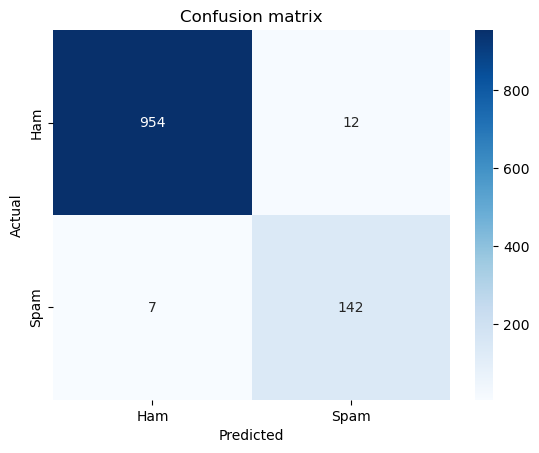

In [10]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',
            cmap='Blues',xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion matrix")
plt.show()

Precision SCORE 0.9530201342281879


In [12]:
import joblib
joblib.dump(model,'email_spam_detection.pkl') # save the model to a file


joblib.dump(vectorizer,'vectorizer.pkl')

['vectorizer.pkl']

 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


SystemExit: 1

/home/amon/anaconda3/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [24]:
from fastapi import FastAPI
import joblib
from pydantic import BaseModel
import uvicorn
import nest_asyncio

# Allow uvicorn to run inside Jupyter
nest_asyncio.apply()

# Load model and vectorizer
model = joblib.load("email_spam_detection.pkl")
vectorizer = joblib.load("vectorizer.pkl")

# App
app = FastAPI()

class Emaildet(BaseModel):
    message: str

@app.post("/predict_email")
def predict_email(data: Emaildet):
    msg = vectorizer.transform([data.message])
    proba = model.predict_proba(msg)[0, 1]  # P(spam)

    # Security-oriented threshold (picked from sweep)
    threshold = 0.30
    is_spam = proba >= threshold
    label = "spam" if is_spam else "ham"

    return {
        "prediction": label,
        "spam_probability": float(proba),
        "threshold": threshold,
    }

# Run server
uvicorn.run(app, host="0.0.0.0", port=8000)


/home/amon/anaconda3/lib/python3.13/genericpath.py:113: RuntimeWarning: coroutine 'Server.serve' was never awaited
  m = tuple(map(os.fspath, m))


RuntimeError: asyncio.run() cannot be called from a running event loop

In [21]:
!python -m pip install "uvicorn[standard]"

  Using cached uvicorn-0.38.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached httptools-0.7.1-cp313-cp313-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (3.5 kB)
  Using cached uvloop-0.22.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (4.9 kB)
  Using cached watchfiles-1.1.1-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.9 kB)
  Using cached websockets-15.0.1-cp313-cp313-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.8 kB)
Using cached uvicorn-0.38.0-py3-none-any.whl (68 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 14.6 kB/s eta 0:00:00m eta -:--:--0:05:08
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [watchfiles] 2/5 [uvicorn]
